In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fontTools.diff import color

sns.set_style("whitegrid")

In [2]:
# Load bootstrap results
results = pd.read_csv(
    "project_data/simulation_demand_results.csv"
)

print("Shape:", results.shape)
print("\nColumns:")
print(results.columns.tolist())

results.head()

Shape: (1000, 11)

Columns:
['Bootstrap', 'Weekday_Cost', 'Saturday_Cost', 'Weekly_Cost', 'Total_Route_Demand', 'Weekday_Owned', 'Weekday_Leased', 'Saturday_Owned', 'Saturday_Leased', 'Weekday_Skipped', 'Saturday_Skipped']


,Bootstrap,Weekday_Cost,Saturday_Cost,Weekly_Cost,Total_Route_Demand,Weekday_Owned,Weekday_Leased,Saturday_Owned,Saturday_Leased,Weekday_Skipped,Saturday_Skipped
0,1,50686.01,23028.46,276458.51,670,37,0,24,0,11,0
1,2,50504.27,23313.18,275834.53,668,36,0,25,0,11,0
2,3,50062.35,23494.04,273805.79,672,35,0,24,0,11,0
3,4,49649.33,22946.82,271193.47,657,37,0,24,0,11,0
4,5,50098.01,22681.03,273171.08,662,37,0,23,0,11,0


In [3]:
# Find the weekly cost column
possible_cost_columns = [
    "Weekly_Cost_NZD",
    "Weekly_Cost",
    "Total_Weekly_Cost",
    "Cost_NZD",
    "Total_Cost_NZD"
]

cost_column = next(
    (col for col in possible_cost_columns if col in results.columns),
    None
)

if cost_column is None:
    raise ValueError(
        "Could not find the weekly cost column. "
        "Available columns are: "
        + str(results.columns.tolist())
    )

print("Using cost column:", cost_column)

weekly_cost = results[cost_column].dropna()

Using cost column: Weekly_Cost


In [4]:
mean_cost = weekly_cost.mean()
median_cost = weekly_cost.median()
std_cost = weekly_cost.std()

p5 = weekly_cost.quantile(0.05)
p95 = weekly_cost.quantile(0.95)

minimum = weekly_cost.min()
maximum = weekly_cost.max()

print(f"Mean:       ${mean_cost:,.2f}")
print(f"Median:     ${median_cost:,.2f}")
print(f"SD:         ${std_cost:,.2f}")
print(f"5th %ile:   ${p5:,.2f}")
print(f"95th %ile:  ${p95:,.2f}")
print(f"Minimum:    ${minimum:,.2f}")
print(f"Maximum:    ${maximum:,.2f}")

Mean:       $272,966.66
Median:     $273,314.66
SD:         $3,222.99
5th %ile:   $266,450.08
95th %ile:  $277,474.22
Minimum:    $256,463.41
Maximum:    $281,750.57


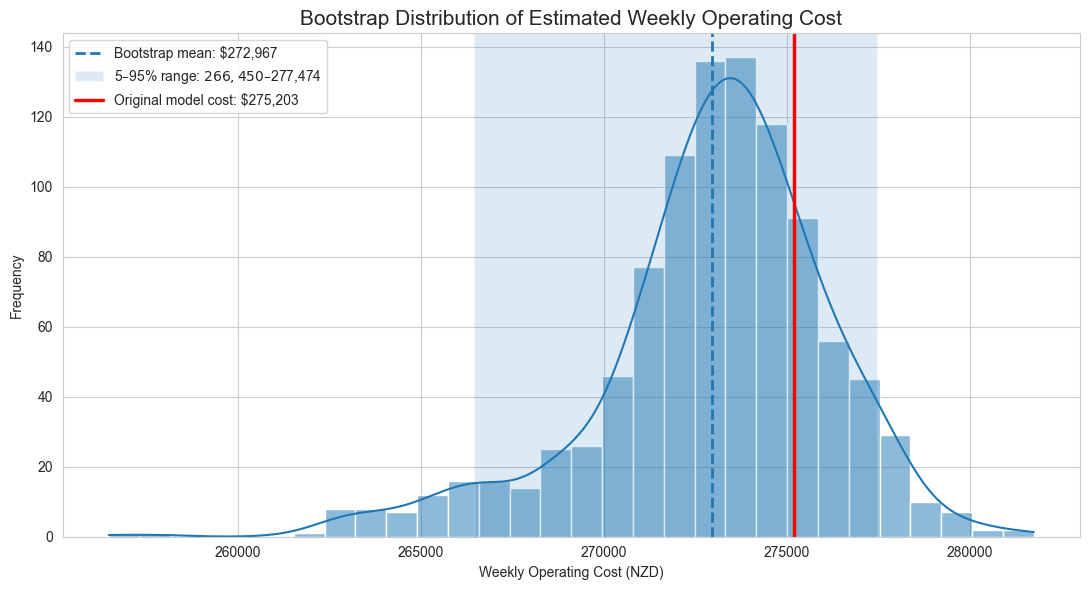

In [5]:
# Original modelled / costed weekly cost
costed_weekly_cost = 275_203.11

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    weekly_cost,
    bins=30,
    kde=True,
    ax=ax
)

# Bootstrap mean
ax.axvline(
    mean_cost,
    linestyle="--",
    linewidth=2,
    label=f"Bootstrap mean: ${mean_cost:,.0f}"
)

# 5th–95th percentile range
ax.axvspan(
    p5,
    p95,
    alpha=0.15,
    label=f"5–95% range: ${p5:,.0f}–${p95:,.0f}"
)

# Original modelled cost
ax.axvline(
    costed_weekly_cost,
    color="red",
    linestyle="-",
    linewidth=2.5,
    label=f"Original model cost: ${costed_weekly_cost:,.0f}"
)

ax.set_title(
    "Bootstrap Distribution of Estimated Weekly Operating Cost",
    fontsize=15
)

ax.set_xlabel("Weekly Operating Cost (NZD)")
ax.set_ylabel("Frequency")

ax.legend()

plt.tight_layout()
plt.show()

In [6]:
# Use Saturday cost
saturday_cost = results["Saturday_Cost"].dropna()

mean_cost = saturday_cost.mean()
median_cost = saturday_cost.median()
std_cost = saturday_cost.std()

p5 = saturday_cost.quantile(0.05)
p95 = saturday_cost.quantile(0.95)

minimum = saturday_cost.min()
maximum = saturday_cost.max()

print(f"Mean:       ${mean_cost:,.2f}")
print(f"Median:     ${median_cost:,.2f}")
print(f"SD:         ${std_cost:,.2f}")
print(f"5th %ile:   ${p5:,.2f}")
print(f"95th %ile:  ${p95:,.2f}")
print(f"Minimum:    ${minimum:,.2f}")
print(f"Maximum:    ${maximum:,.2f}")

Mean:       $23,225.43
Median:     $23,234.27
SD:         $375.20
5th %ile:   $22,603.87
95th %ile:  $23,825.12
Minimum:    $21,942.02
Maximum:    $24,341.38


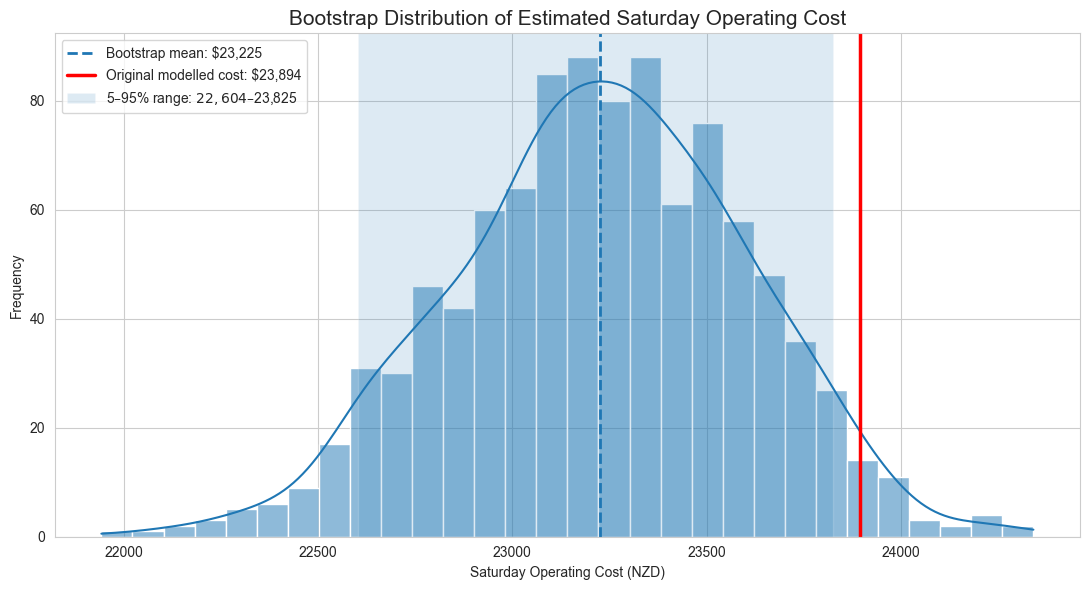

In [7]:
# Original modelled / costed Saturday cost
costed_saturday_cost = 23_894.01

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    saturday_cost,
    bins=30,
    kde=True,
    ax=ax
)

# Mean
ax.axvline(
    mean_cost,
    linestyle="--",
    linewidth=2,
    label=f"Bootstrap mean: ${mean_cost:,.0f}"
)

# Original costed value
ax.axvline(
    costed_saturday_cost,
    color="red",
    linestyle="-",
    linewidth=2.5,
    label=f"Original modelled cost: ${costed_saturday_cost:,.0f}"
)

# 5–95% range
ax.axvspan(
    p5,
    p95,
    alpha=0.15,
    label=f"5–95% range: ${p5:,.0f}–${p95:,.0f}"
)

ax.set_title(
    "Bootstrap Distribution of Estimated Saturday Operating Cost",
    fontsize=15
)

ax.set_xlabel(
    "Saturday Operating Cost (NZD)"
)

ax.set_ylabel(
    "Frequency"
)

ax.legend()

plt.tight_layout()
plt.show()

In [8]:
# Total route demand from each bootstrap realisation
saturday_demand = (
    results["Total_Route_Demand"]
    .dropna()
)

mean_demand = saturday_demand.mean()
median_demand = saturday_demand.median()
std_demand = saturday_demand.std()

p5_demand = saturday_demand.quantile(0.05)
p95_demand = saturday_demand.quantile(0.95)

minimum_demand = saturday_demand.min()
maximum_demand = saturday_demand.max()

print(f"Mean:       {mean_demand:.2f} pallets")
print(f"Median:     {median_demand:.2f} pallets")
print(f"SD:         {std_demand:.2f} pallets")
print(f"5th %ile:   {p5_demand:.2f} pallets")
print(f"95th %ile:  {p95_demand:.2f} pallets")
print(f"Minimum:    {minimum_demand:.2f} pallets")
print(f"Maximum:    {maximum_demand:.2f} pallets")

Mean:       663.43 pallets
Median:     664.00 pallets
SD:         7.72 pallets
5th %ile:   650.00 pallets
95th %ile:  675.00 pallets
Minimum:    633.00 pallets
Maximum:    685.00 pallets


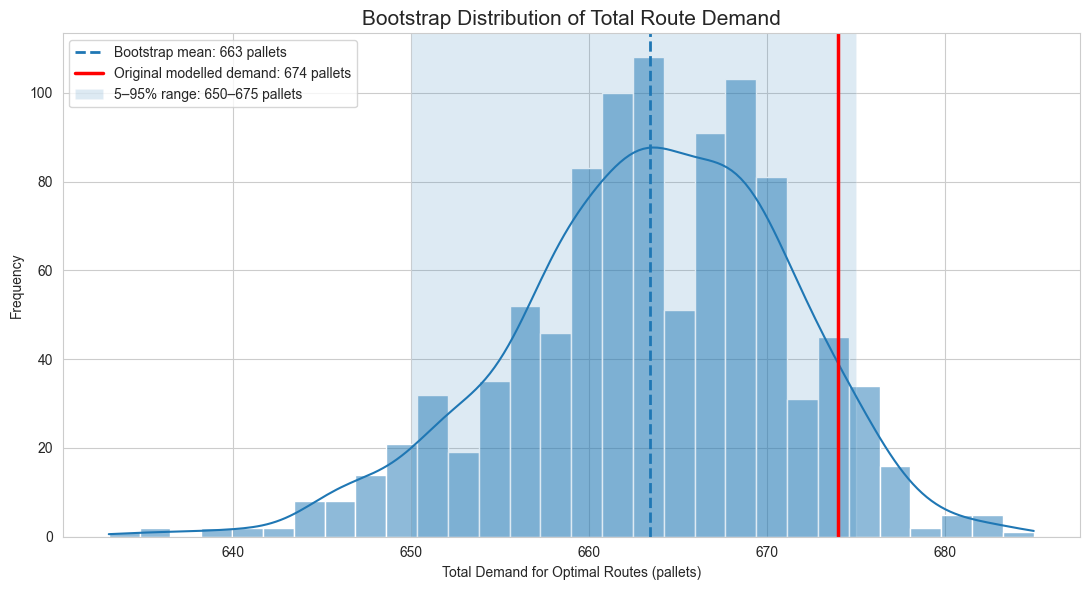

In [9]:
costed_demand = 674

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    saturday_demand,
    bins=30,
    kde=True,
    ax=ax
)

ax.axvline(
    mean_demand,
    linestyle="--",
    linewidth=2,
    label=f"Bootstrap mean: {mean_demand:.0f} pallets"
)

ax.axvline(
    costed_demand,
    color="red",
    linestyle="-",
    linewidth=2.5,
    label=f"Original modelled demand: {costed_demand} pallets"
)

ax.axvspan(
    p5_demand,
    p95_demand,
    alpha=0.15,
    label=f"5–95% range: {p5_demand:.0f}–{p95_demand:.0f} pallets"
)

ax.set_title(
    "Bootstrap Distribution of Total Route Demand",
    fontsize=15
)

ax.set_xlabel(
    "Total Demand for Optimal Routes (pallets)"
)

ax.set_ylabel("Frequency")

ax.legend()

plt.tight_layout()
plt.show()